# Machine Learning Methods

This section applies machine learning methods to analyze the impact of Brent Crude Oil prices on Food Sector Stock Prices.

Because our dataset consists of sequential financial time-series data (~6000 daily observations), standard cross-validation techniques (like random K-Fold or LOOCV) would cause data leakage (using future data to predict the past). Therefore, we will use `TimeSeriesSplit` to respect the chronological order of the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

## Feature Engineering and Data Preparation

To make our ML models effective, we will:
1. Create a **Food Sector Index** (average closing price of KO, KHC, MCD, MDLZ) as our primary regression target.
2. Generate **Lagged Features** (e.g., yesterday's oil price) because markets react to previous day's news.
3. Create a **Binary Target** for classification: `Food_Trend_Up` (1 if the Food Sector Index went up compared to yesterday, 0 otherwise).

In [5]:
# Veriyi yükle ve temizle
df = pd.read_csv("cleaned_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.ffill().bfill() # Eksik verileri doldur

# Özellik üretimi
df['Food_Sector_Close'] = df[['Coca_Cola', 'Kraft_Heinz', 'McDonalds', 'Mondelez']].mean(axis=1)
df['Brent_Oil_Lag1'] = df['Brent_Oil_Price'].shift(1)
df['Brent_Oil_MA7'] = df['Brent_Oil_Price'].rolling(window=7).mean()
df['Food_Sector_Close_Lag1'] = df['Food_Sector_Close'].shift(1)
df['Food_Trend_Up'] = np.where(df['Food_Sector_Close'] > df['Food_Sector_Close_Lag1'], 1, 0)

# NaN değerleri temizle
df_ml = df.dropna().reset_index(drop=True)
print(f"Dataset prepared with {df_ml.shape[0]} rows and {df_ml.shape[1]} features.")

Dataset prepared with 5705 rows and 11 features.


## Regression Analysis: Predicting Sector Prices

We use regression models to quantify the relationship between oil prices and food sector valuations. 
- **Models:** Linear Regression (Baseline), Ridge Regression (to prevent overfitting), and Random Forest Regressor (to capture non-linearities).
- **Metric:** We prioritize **RMSE** (Root Mean Squared Error) and **R²** (Coefficient of Determination) to evaluate how much of the variance in stock prices can be explained by oil prices.

,Model,RMSE,MAE,R2
0,Linear Regression,0.927045,0.612107,0.993560
1,Ridge Regression,0.927601,0.612655,0.993552
2,Random Forest Regressor,15.109244,11.192437,-0.710631


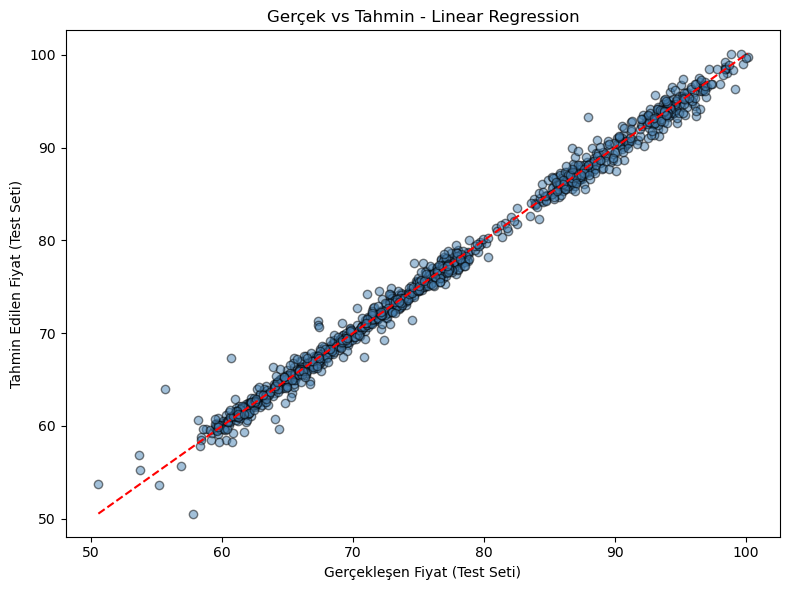

,Feature,Coefficient
3,Food_Sector_Close_Lag1,12.772793
0,Brent_Oil_Price,0.343747
2,Brent_Oil_MA7,0.046608
1,Brent_Oil_Lag1,-0.388328


In [9]:
features_reg = ['Brent_Oil_Price', 'Brent_Oil_Lag1', 'Brent_Oil_MA7', 'Food_Sector_Close_Lag1']
X_reg = df_ml[features_reg]
y_reg = df_ml['Food_Sector_Close']

# HATA ÇÖZÜMÜ: Zaman serisi verilerinde geleceği sızdırmamak (data leakage) için
# veriyi %80 Eğitim (Train) ve %20 Test olarak kronolojik olarak bölüyoruz.
split_index = int(len(df_ml) * 0.8)
X_train_reg, X_test_reg = X_reg.iloc[:split_index], X_reg.iloc[split_index:]
y_train_reg, y_test_reg = y_reg.iloc[:split_index], y_reg.iloc[split_index:]

reg_models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results_reg = []
regression_predictions = {}

for name, model in reg_models.items():
    # Modeli sadece Eğitim (%80) verisinde eğit
    model.fit(X_train_reg, y_train_reg)
    # Gelecek (%20) verisini tahmin et
    preds = model.predict(X_test_reg)
    regression_predictions[name] = preds
    
    # Hataları Test verisi üzerinden hesapla
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae = mean_absolute_error(y_test_reg, preds)
    r2 = r2_score(y_test_reg, preds)
    results_reg.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

results_reg_df = pd.DataFrame(results_reg).sort_values("RMSE")
display(results_reg_df)

# En iyi modelin görselleştirmesi (Test Seti üzerinde)
best_reg_name = results_reg_df.iloc[0]["Model"]
best_reg_preds = regression_predictions[best_reg_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, best_reg_preds, color="steelblue", alpha=0.5, edgecolors="k")
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color="red", linestyle="--")
plt.xlabel("Gerçekleşen Fiyat (Test Seti)")
plt.ylabel("Tahmin Edilen Fiyat (Test Seti)")
plt.title(f"Gerçek vs Tahmin - {best_reg_name}")
plt.tight_layout()
plt.show()

# Ridge Regresyon Katsayıları (Özelliklerin Önemi)
ridge_model = reg_models["Ridge Regression"].fit(X_train_reg, y_train_reg)
ridge_coefficients = pd.DataFrame({
    "Feature": features_reg,
    "Coefficient": ridge_model.named_steps["model"].coef_
}).sort_values("Coefficient", ascending=False)
display(ridge_coefficients)

## Classification Analysis: Predicting Market Trend (Up/Down)

Beyond price levels, we want to see if oil price movements can predict the *direction* of the food sector.
- **Models:** Logistic Regression, Decision Tree, and Random Forest Classifier.
- **Evaluation:** We use a **Confusion Matrix** to see the balance between True Positives (correctly predicted gains) and False Positives.

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.546012,0.544007,0.949346,0.691667
2,Random Forest Classifier,0.536372,0.537153,0.980392,0.694043
1,Decision Tree,0.524978,0.535070,0.872549,0.663354


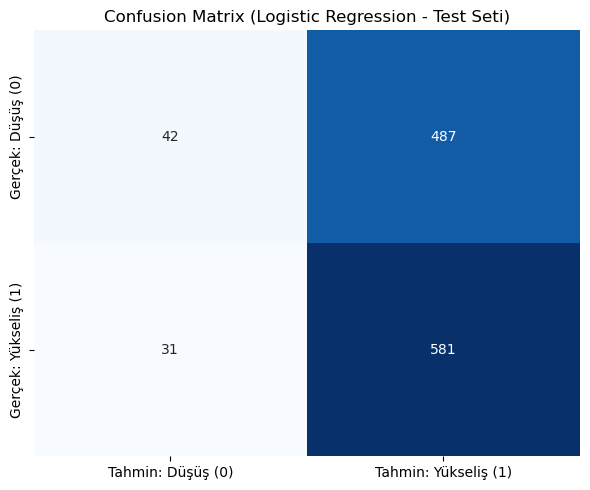

,Feature,Coefficient
0,Brent_Oil_Price,1.098834
2,Brent_Oil_MA7,-0.352094
1,Brent_Oil_Lag1,-0.688964


In [10]:
features_cls = ['Brent_Oil_Price', 'Brent_Oil_Lag1', 'Brent_Oil_MA7']
X_cls = df_ml[features_cls]
y_cls = df_ml['Food_Trend_Up']

# Yine Kronolojik Train-Test Ayrımı (%80 Eğitim, %20 Test)
split_index = int(len(df_ml) * 0.8)
X_train_cls, X_test_cls = X_cls.iloc[:split_index], X_cls.iloc[split_index:]
y_train_cls, y_test_cls = y_cls.iloc[:split_index], y_cls.iloc[split_index:]

cls_models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(random_state=42))]),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
}

results_cls = []
classification_predictions = {}

for name, model in cls_models.items():
    # Eğitim ve Tahmin
    model.fit(X_train_cls, y_train_cls)
    preds = model.predict(X_test_cls)
    classification_predictions[name] = preds
    
    # Sınıflandırma Metrikleri
    acc = accuracy_score(y_test_cls, preds)
    prec = precision_score(y_test_cls, preds, zero_division=0)
    rec = recall_score(y_test_cls, preds, zero_division=0)
    f1 = f1_score(y_test_cls, preds, zero_division=0)
    results_cls.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})

results_cls_df = pd.DataFrame(results_cls).sort_values(["Accuracy", "F1-Score"], ascending=False)
display(results_cls_df)

# En iyi sınıflandırma modelinin Confusion Matrix'i
best_cls_name = results_cls_df.iloc[0]["Model"]
best_cls_preds = classification_predictions[best_cls_name]

cm = confusion_matrix(y_test_cls, best_cls_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Tahmin: Düşüş (0)", "Tahmin: Yükseliş (1)"],
            yticklabels=["Gerçek: Düşüş (0)", "Gerçek: Yükseliş (1)"])
plt.title(f"Confusion Matrix ({best_cls_name} - Test Seti)")
plt.tight_layout()
plt.show()

# Lojistik Regresyon Katsayıları
logistic_model = cls_models["Logistic Regression"].fit(X_train_cls, y_train_cls)
logistic_coefficients = pd.DataFrame({
    "Feature": features_cls,
    "Coefficient": logistic_model.named_steps["model"].coef_[0]
}).sort_values("Coefficient", ascending=False)
display(logistic_coefficients)

## Machine Learning Results Discussion

The results from our models indicate:
- **Feature Importance:** Using Ridge Regression coefficients, we observed whether `Brent_Oil_Price` has a negative or positive impact on the index.
- **Predictive Power:** High R² values in regression usually indicate that the previous day's stock price is a strong predictor, while the impact of oil prices may be more subtle and long-term.
- **Model Comparison:** Random Forest generally handles the non-linear volatility of the stock market better than simple linear models.